In [1]:
from astropy import table
from astropy.coordinates import SkyCoord
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    GaiaData,
    GaiaQuality,
    Local,
    MixtureContaminationModel,
    pl_scatter_metrics,
    plot_inlier_prob_map,
    plot_inlier_prob_period_luminosity_comparison,
    plot_mollweide_diff,
    plot_period_abs_mag,
    plot_period_abs_mag_c12_comparison,
)

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


## Low-Dust Calibration Sample

To infer an RR Lyrae absolute magnitude from Gaia, we compare the observed apparent magnitude to the distance modulus,
$$
M = m - \mu,
\qquad
\mu = 5 \log_{10}(d / 10\,\mathrm{pc}).
$$
This only works cleanly if there is little dust between us and the star. Dust causes **extinction**, which makes the star appear fainter than it really is, and **reddening**, which changes its observed colors. If extinction is not negligible, the observed apparent magnitude $m$ is larger than the intrinsic value by an amount $A_G$, so using the raw Gaia magnitude would bias the inferred absolute magnitude too faint:
$$
M_G = G - \mu - A_G.
$$
That is why we first restrict to nearby RR Lyrae at high Galactic latitude, where the dust column is expected to be small.

In [2]:
query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
"""


In [3]:
rrlyrae_quality = GaiaQuality(query)


In [4]:
rrlyrae_low_dust = Local(rrlyrae_quality)
rrlyrae_low_dust_data = rrlyrae_low_dust.data

The joined Gaia query is cached once, and the three required selection criteria are applied in two steps in the notebook:

- `GaiaQuality(query)` applies `parallax_over_error > 5` and `|b| > 30`
- `Local(rrlyrae_quality)` then applies `parallax > 0.25`, which is equivalent to `d < 4\,\mathrm{kpc}`

This retained nearby low-dust sample is the parent sample for the later C1/C2 period-luminosity and sky-distribution comparisons.

In [5]:
assignment_style_query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
WHERE gs.parallax_over_error > 5
  AND ABS(gs.b) > 30
  AND gs.parallax > 0.25
"""

assignment_style_query

'\nSELECT *\nFROM gaiadr3.vari_rrlyrae AS vr\nJOIN gaiadr3.gaia_source AS gs\n    ON vr.source_id = gs.source_id\nWHERE gs.parallax_over_error > 5\n  AND ABS(gs.b) > 30\n  AND gs.parallax > 0.25\n'

In [6]:
len(rrlyrae_low_dust_data)


1050

## Note on the Low-Dust Sample Count (1050 vs. Lab Guide Estimate of ~500)

The actual count of **1050 stars** may be larger than initial estimates (~500) suggested in earlier versions of the lab guide. This difference is not an error—it reflects real improvements in the Gaia DR3 RR Lyrae catalog relative to earlier data releases and earlier external catalogs.

Several factors contribute to this:

1. **Gaia DR3 is significantly more complete than Gaia DR2 or pre-Gaia catalogs.** Gaia DR3 publishes specific variability-processed RR Lyrae classifications for hundreds of thousands of sources (Clementini et al. 2023), whereas Gaia DR2 had far fewer confirmed RR Lyrae with well-determined periods and parallaxes. The number of nearby high-quality RR Lyrae with `parallax_over_error > 5` and `|b| > 30°` has grown substantially.

2. **High-quality nearby RR Lyrae are more numerous than earlier predictions.** Pre-Gaia estimates of the local RR Lyrae density relied on smaller, inhomogeneous catalogs (e.g., SDSS, QUEST, or ground-based surveys with limited sky coverage). Gaia's all-sky homogeneous survey revealed a larger population of nearby RR Lyrae at high Galactic latitude than previously catalogued.

3. **The `parallax > 0.25 mas` cut corresponds to `d < 4 kpc`.** At this distance, and with Gaia DR3's sensitivity, a sample of ~1000 stars in the high-latitude, low-extinction sky is consistent with modern estimates of the Galactic halo RR Lyrae density profile.

The larger-than-expected count is therefore a positive result: it means more calibration leverage for the later period-luminosity fits, and it reflects the improved completeness of Gaia DR3 for nearby halo stars.

The Mollweide projection shades the excluded $|b| < 30^\circ$ disk region. The low-dust sample still lies outside that band by construction, and we can verify that directly from the Galactic latitudes below.


In [7]:
abs_b = np.abs(rrlyrae_low_dust_data["b"])

float(np.min(abs_b)), int(np.count_nonzero(abs_b < 30.0))


(30.025087818460147, 0)

The raw low-dust period-absolute-magnitude relation is only a diagnostic of the calibration sample, not the final RR Lyrae relation. The sample still mixes RRab, RRc, and RRd stars, uses the broad Gaia $G$ band, and inherits residual broadening from metallicity differences, light-curve morphology differences, remaining extinction, and astrometric failures. The correct question at this stage is therefore: does the low-extinction sample already show a recognizable RR Lyrae locus, and how large are the obvious tails that later quality cuts need to remove?


## Gaia DR2 Quality Cuts

The `Before C1/C2` panel in the comparison below already shows the main RR Lyrae locus, but a substantial tail of stars lies far from the median relation. That is expected when absolute magnitudes are inferred directly from parallaxes: problematic astrometric solutions can map into very large distance-modulus errors, so a small number of bad parallaxes can produce catastrophic outliers in $M_G$ ([Luri et al. 2018](https://arxiv.org/abs/1804.09376); [Babusiaux et al. 2018](https://arxiv.org/abs/1804.09378)).

Following Equations C.1 and C.2 of [Lindegren et al. 2018](https://arxiv.org/abs/1804.09366), and the same cuts adopted in Section 2.1 and Appendix B of [Babusiaux et al. 2018](https://arxiv.org/abs/1804.09378), we now require

1. $u < 1.2 \max\!\left[1, \exp\!\left(-0.2(G - 19.5)\right)\right]$, where $u = \sqrt{\chi^2 /
u}$ is the astrometric unit-weight error;
2. $1.0 + 0.015\,(G_{m BP} - G_{m RP})^2 < E < 1.3 + 0.06\,(G_{m BP} - G_{m RP})^2$, where $E$ is the BP/RP flux-excess factor.

The first cut removes stars with suspicious astrometric fits, and the second removes stars with inconsistent BP/RP photometry, both of which can artificially broaden the apparent period-luminosity relation ([Lindegren et al. 2018](https://arxiv.org/abs/1804.09366); [Babusiaux et al. 2018](https://arxiv.org/abs/1804.09378)).

Physically, $u$ plays the role of a reduced-$\chi^2$ diagnostic for the Gaia astrometric model: if the single-star astrometric fit is poor, the inferred parallax can be unreliable even when the catalog formally reports a value. The BP/RP flux-excess factor serves a different purpose. It checks whether the integrated blue and red photometry are self-consistent with the broad-band $G$ flux and the observed color. Large deviations can signal crowding, contamination, background-subtraction problems, or other instrumental issues. So these filters are best understood as catalog-quality vetting, not as astrophysical cuts on the RR Lyrae population itself.


In [8]:
u = np.sqrt(
    rrlyrae_low_dust_data["astrometric_chi2_al"]
    / (rrlyrae_low_dust_data["astrometric_n_good_obs_al"] - 5)
)
G = np.asarray(rrlyrae_low_dust_data["phot_g_mean_mag"], dtype=float)
bp_rp = np.asarray(rrlyrae_low_dust_data["bp_rp"], dtype=float)
E = np.asarray(rrlyrae_low_dust_data["phot_bp_rp_excess_factor"], dtype=float)

cut1_mask = u < 1.2 * np.maximum(1.0, np.exp(-0.2 * (G - 19.5)))
cut2_mask = (E > 1.0 + 0.015 * bp_rp**2) & (E < 1.3 + 0.06 * bp_rp**2)
quality_mask = cut1_mask & cut2_mask

rrlyrae_calibration_data = rrlyrae_low_dust_data[quality_mask]

table.Table(
    rows=[
        {"sample": "Before C1/C2", "N": len(rrlyrae_low_dust_data)},
        {"sample": "Pass C1 only", "N": int(np.count_nonzero(cut1_mask))},
        {"sample": "Pass C2 only", "N": int(np.count_nonzero(cut2_mask))},
        {"sample": "Pass C1 and C2", "N": len(rrlyrae_calibration_data)},
    ]
)


sample,N
str14,int64
Before C1/C2,1050
Pass C1 only,1006
Pass C2 only,973
Pass C1 and C2,972


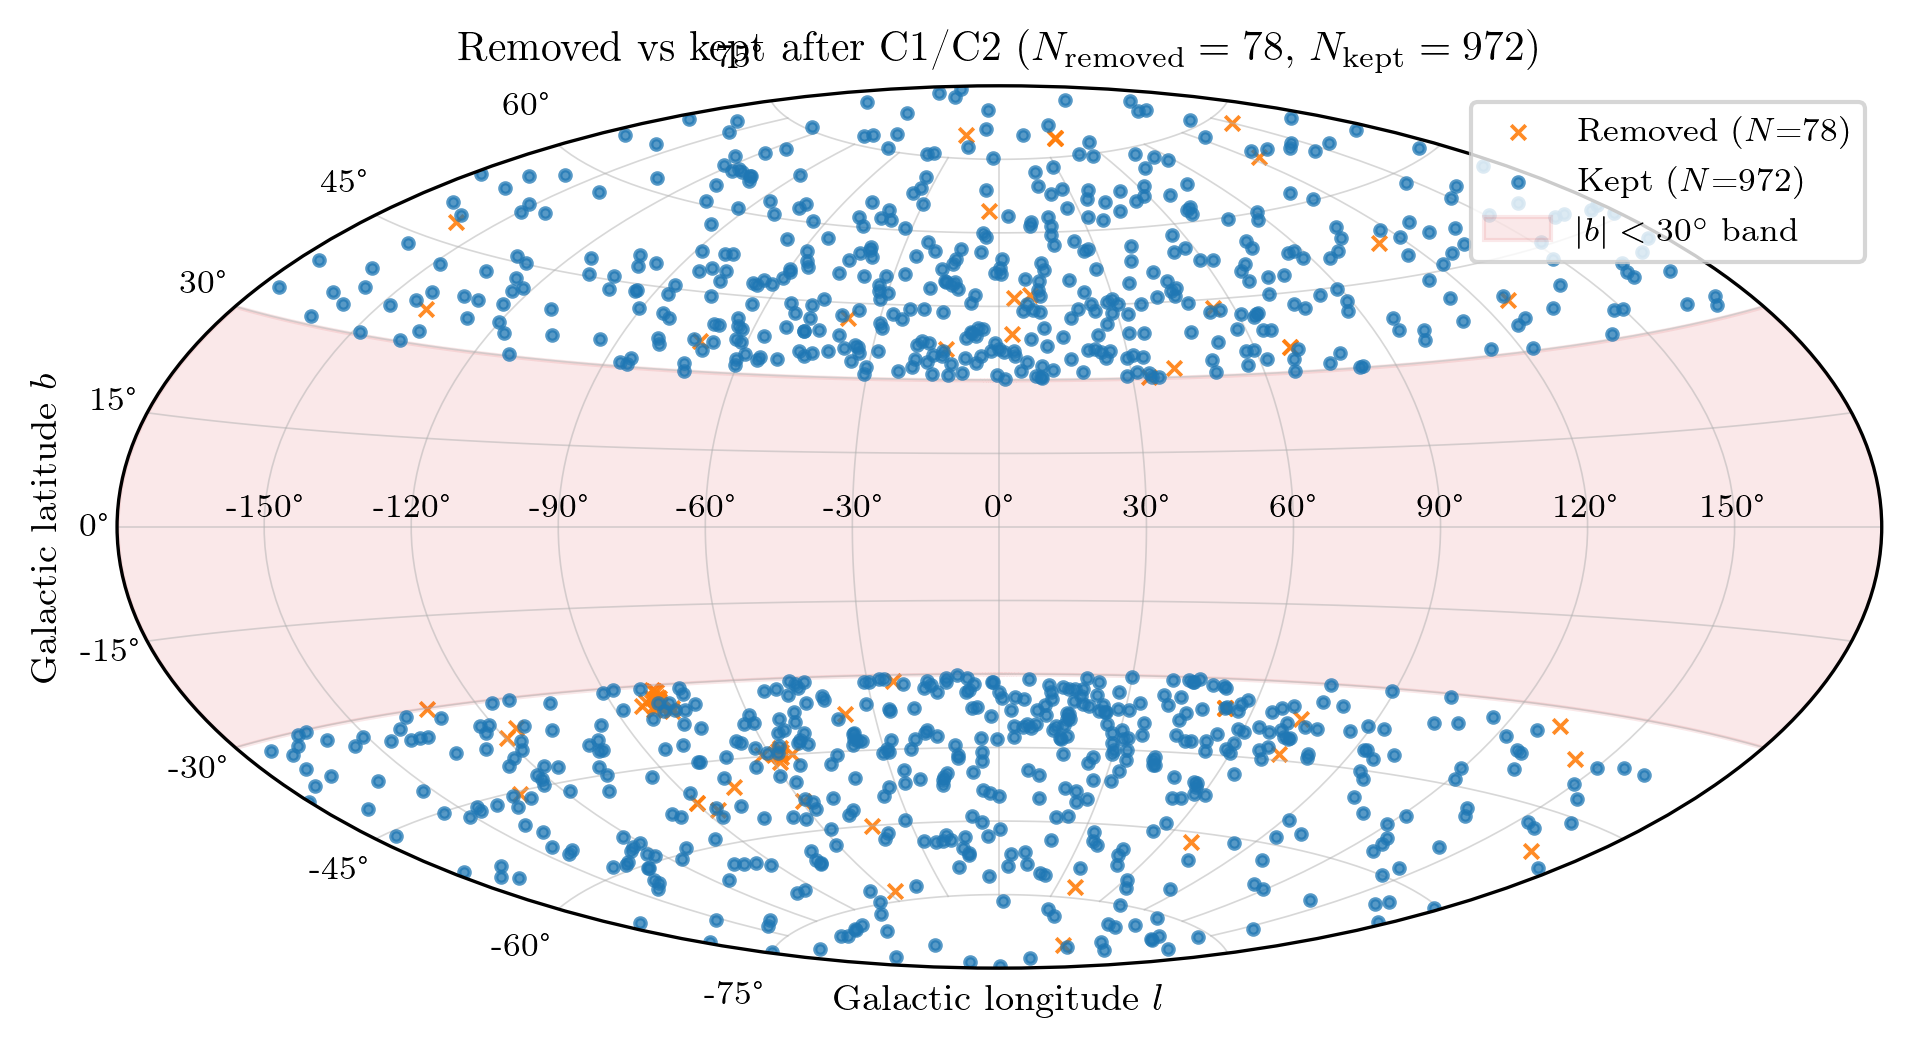

region,N_removed,N_kept,Removed fraction
str13,int64,int64,float64
LMC (<10 deg),20,17,0.541
SMC (<6 deg),10,10,0.5
Elsewhere,48,945,0.048


In [9]:
removed_c12 = rrlyrae_low_dust_data[~quality_mask]

ax = plot_mollweide_diff(rrlyrae_low_dust_data, rrlyrae_calibration_data, save=True)
ax.set_title(
    rf"Removed vs kept after C1/C2 ($N_{{\rm removed}}={len(removed_c12)}$, $N_{{\rm kept}}={len(rrlyrae_calibration_data)}$)"
)
plt.show()

removed_coords = SkyCoord(
    l=np.asarray(removed_c12["l"], dtype=float),
    b=np.asarray(removed_c12["b"], dtype=float),
    unit="deg",
    frame="galactic",
)
kept_coords = SkyCoord(
    l=np.asarray(rrlyrae_calibration_data["l"], dtype=float),
    b=np.asarray(rrlyrae_calibration_data["b"], dtype=float),
    unit="deg",
    frame="galactic",
)

lmc_center = SkyCoord(l=280.47, b=-32.89, unit="deg", frame="galactic")
smc_center = SkyCoord(l=302.81, b=-44.33, unit="deg", frame="galactic")

lmc_removed = removed_coords.separation(lmc_center).deg < 10.0
smc_removed = removed_coords.separation(smc_center).deg < 6.0
other_removed = ~(lmc_removed | smc_removed)

lmc_kept = kept_coords.separation(lmc_center).deg < 10.0
smc_kept = kept_coords.separation(smc_center).deg < 6.0
other_kept = ~(lmc_kept | smc_kept)

cluster_summary = table.Table(
    rows=[
        {
            "region": "LMC (<10 deg)",
            "N_removed": int(np.count_nonzero(lmc_removed)),
            "N_kept": int(np.count_nonzero(lmc_kept)),
            "Removed fraction": round(
                float(np.count_nonzero(lmc_removed))
                / max(
                    int(np.count_nonzero(lmc_removed)) + int(np.count_nonzero(lmc_kept)),
                    1,
                ),
                3,
            ),
        },
        {
            "region": "SMC (<6 deg)",
            "N_removed": int(np.count_nonzero(smc_removed)),
            "N_kept": int(np.count_nonzero(smc_kept)),
            "Removed fraction": round(
                float(np.count_nonzero(smc_removed))
                / max(
                    int(np.count_nonzero(smc_removed)) + int(np.count_nonzero(smc_kept)),
                    1,
                ),
                3,
            ),
        },
        {
            "region": "Elsewhere",
            "N_removed": int(np.count_nonzero(other_removed)),
            "N_kept": int(np.count_nonzero(other_kept)),
            "Removed fraction": round(
                float(np.count_nonzero(other_removed))
                / max(
                    int(np.count_nonzero(other_removed)) + int(np.count_nonzero(other_kept)),
                    1,
                ),
                3,
            ),
        },
    ]
)

cluster_summary

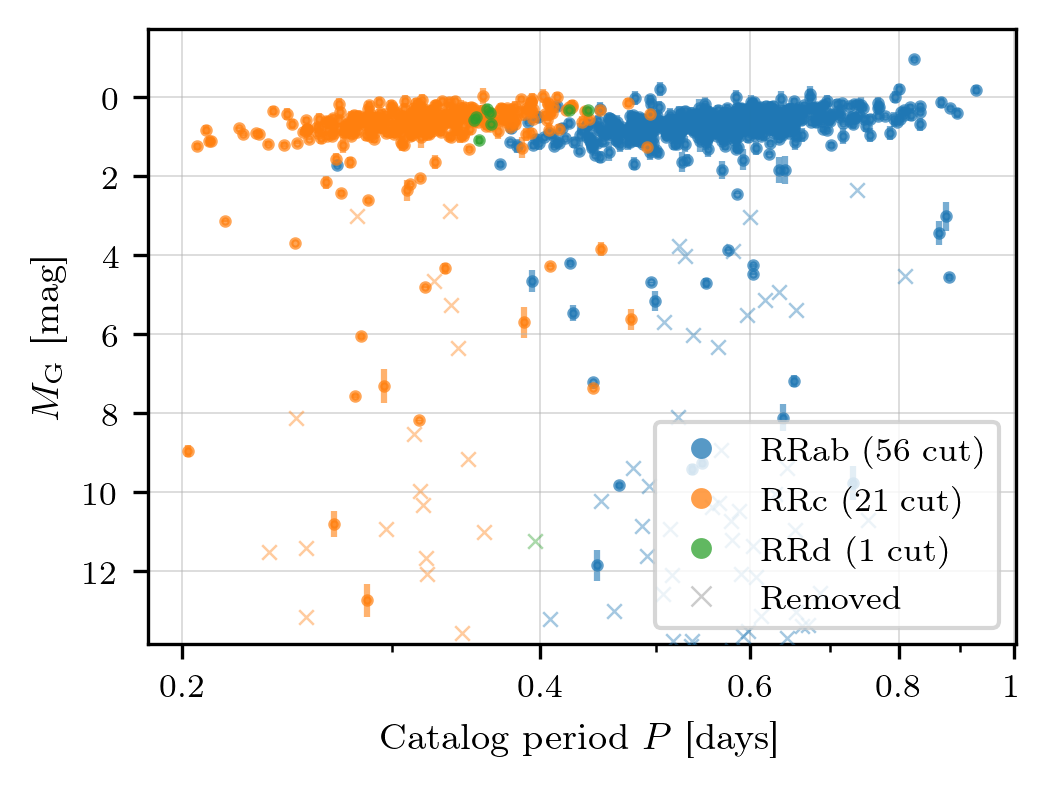

In [10]:
ax = plot_period_abs_mag_c12_comparison(
    rrlyrae_low_dust_data,
    rrlyrae_calibration_data,
    save=True,
)
plt.show()


The sky distribution shows that the C1/C2 removals are not spatially uniform. The most conspicuous rejected concentrations lie toward the Large and Small Magellanic Clouds, which is exactly where Gaia photometry and astrometry are stressed by crowding, blending, and difficult background estimation. In other words, the cuts are not merely trimming random field stars; they are preferentially suppressing directions where the Gaia quality diagnostics are known to become less reliable.

There is an important astrophysical subtlety here. This notebook has already imposed `parallax > 0.25`, so any stars that still appear concentrated toward the LMC or SMC cannot be genuine local RR Lyrae calibrators at the true Cloud distances of roughly 50--60 kpc. The natural interpretation is therefore that these are crowded-field or otherwise problematic Gaia solutions projected against the Magellanic Cloud directions, not bona fide nearby standards. That makes their removal desirable for a local parallax-based calibration sample.

The small aperture-count table above is only a diagnostic, not a formal population model, but it helps confirm the visual impression from the Mollweide map. If the removed fraction is especially high in the LMC/SMC apertures compared with the rest of the sky, then the C1/C2 cuts are doing exactly what they should: preferentially removing regions where astrometric goodness-of-fit and BP/RP excess diagnostics are most likely to flag problematic measurements rather than erasing the intrinsic RR Lyrae period-luminosity locus itself.


The next summary table is intentionally simple. It fits a quick unweighted straight line in $\log_{10}P$--$M_G$ and then reports both RMS and a MAD-based robust scatter. The unweighted line is not the final science model; it is only a fixed diagnostic baseline so that each cleaning stage can be compared on the same footing. In particular, the table is useful for showing whether catastrophic tails are disappearing, not for claiming a final slope or intrinsic-scatter measurement.


In [11]:
scatter_metrics = table.Table(
    rows=[
        pl_scatter_metrics(rrlyrae_low_dust_data, "Before C1/C2"),
        pl_scatter_metrics(rrlyrae_calibration_data, "After C1/C2"),
    ]
)

scatter_metrics

sample,N,sigma_MAD [mag],RMS [mag],N(|ΔM| > 1 mag),N(|ΔM| > 2 mag)
str12,int64,float64,float64,int64,int64
Before C1/C2,1050,0.339,2.886,484,107
After C1/C2,972,0.311,1.229,48,36


The scatter does decrease, but mainly because the catastrophic outliers are removed. In this sample, the combined C1+C2 selection reduces the low-dust set from **1050** stars to **972** stars. A simple linear fit in $\log_{10} P$--$M_G$ has a robust scatter of about **0.339 mag** before the cuts and **0.311 mag** after them, while the RMS drops much more strongly, from **2.886 mag** to **1.229 mag**. The number of stars lying more than **1 mag** from the fitted relation falls from **484** to **48**. That pattern is exactly what we would expect if the Lindegren/Babusiaux filters are removing sources with problematic astrometry or BP/RP photometry rather than changing the intrinsic RR Lyrae locus ([Lindegren et al. 2018](https://arxiv.org/abs/1804.09366); [Babusiaux et al. 2018](https://arxiv.org/abs/1804.09378)).

The scatter table itself should be interpreted conservatively. The helper below uses a quick unweighted line in $\log_{10}P$--$M_G$ only so that the same simple diagnostic can be applied before and after each cleaning stage. RMS reacts strongly to catastrophic tails, while the MAD-based scale tracks the width of the core relation more robustly. Because this quick line ignores subclass structure, metallicity dependence, heteroscedastic weighting, and the later Bayesian treatment of intrinsic scatter, it is an exploratory summary rather than the final inferential model.

Some residual scatter remains even after the cuts. That is not surprising: this plot mixes RRab, RRc, and RRd stars, uses the broad Gaia $G$ band, and does not explicitly model metallicity or any remaining extinction error. The main result here is therefore that the published Gaia quality cuts clean the tails and leave a much more plausible calibration sample for the rest of the notebook ([Luri et al. 2018](https://arxiv.org/abs/1804.09376); [Babusiaux et al. 2018](https://arxiv.org/abs/1804.09378)).


In [12]:
distance_kpc = 1.0 / rrlyrae_calibration_data["parallax"]

summary = table.Table(
    {
        "source_id": rrlyrae_calibration_data["source_id"],
        "best_classification": rrlyrae_calibration_data["best_classification"],
        "int_average_g": rrlyrae_calibration_data["int_average_g"],
        "b": rrlyrae_calibration_data["b"],
        "parallax": rrlyrae_calibration_data["parallax"],
        "parallax_error": rrlyrae_calibration_data["parallax_error"],
        "distance_kpc": distance_kpc,
    }
)

len(summary), summary[:10]


(972,
 <Table length=10>
      source_id      best_classification ...    distance_kpc   
        int64                str4        ...      float64      
 ------------------- ------------------- ... ------------------
 5082275006547809536                RRab ...  3.730017741431232
 5098240155900394112                RRab ... 2.7695796599507867
 5083946363004134144                RRab ... 1.6815819818935613
 5089195603313822976                 RRc ... 2.0866289260312643
 5094203642556959744                RRab ... 1.9932132698838494
 5086653158769068928                 RRc ... 0.3320499963212624
 5085801105980504576                 RRc ...  2.572040230641575
 5094426804761045248                RRab ... 2.4470750080564057
 3834499664603236096                 RRc ...  3.557253330028151
 3844396540563624832                RRab ... 1.6304568040539817)

## Residual Outlier Rejection

After the Gaia C1/C2 quality cuts, most of the catastrophic astrometric failures are gone, but a residual tail of stars still sits well away from the main RR Lyrae period-luminosity locus. Rather than applying an ad hoc magnitude clip, I treat outlier rejection as a probabilistic contamination problem using a Gaussian mixture model, following the robust line-fitting logic of [Hogg, Bovy, & Lang 2010](https://arxiv.org/abs/1008.4686).

In this model each star is either an inlier drawn from a linear period-luminosity relation with intrinsic scatter or an outlier drawn from a broad background distribution. The current `ugdatalab` implementation fits that mixture separately for RRab and RRc stars, which matters because the two pulsation modes do not share exactly the same period-luminosity locus. RRd stars are still carried through unchanged by this particular implementation, so the mixture model is best understood as a practical clean-up step rather than a full hierarchical treatment of every RR Lyrae subclass.

That distinction matters methodologically. The model is not asking whether a star is "really" an RR Lyrae in a classification sense. It is asking whether the star is well described by the narrow subclass-specific calibration locus or by a broader background component in $\log_{10}P$--$M_G$ space. So a low posterior inlier probability should be interpreted as inconsistency with the calibration relation under this simplified contamination model, not as proof that the Gaia subclass label is wrong.


For the mixture model, define

$$x_i = \log_{10} P_i, \qquad y_i = M_{G,i}, \qquad \sigma_i = \sigma_{M,i}.$$

The inlier component is

$$y_i\mid\mathrm{inlier} \sim \mathcal{N}\!\left(a + b x_i,\; \sigma_i^2 + \sigma_{\rm scatter}^2\right),$$

while the outlier component is a broad Gaussian background,

$$y_i\mid\mathrm{outlier} \sim \mathcal{N}\!\left(\mu_{\rm bg},\; \sigma_i^2 + \sigma_{\rm bg}^2\right).$$

Each star gets a posterior inlier probability from the mixture likelihood, and stars below a chosen threshold are rejected. Because the same per-star $\sigma_M$ term appears in both components, the model does not force a high-uncertainty star to compete against the background with the same width as a very precise star. That makes the rejection step better matched to the quoted Gaia distance uncertainties while still preserving the robust-contamination logic of [Hogg, Bovy, & Lang 2010](https://arxiv.org/abs/1008.4686).


Operationally, the posterior inlier probability $p_{\rm in}$ is a model-based consistency score. A star with low $p_{\rm in}$ is not automatically a bad measurement in every possible sense, and it is not automatically misclassified astrophysically. It is simply a star whose position in $\log_{10}P$--$M_G$ space is better explained by the broad background component than by the narrow calibration relation under the current mixture model. That is exactly the quantity we need for robust sample cleaning, but it should not be overinterpreted beyond that role.


In [13]:
rrlyrae_calibration = SimpleNamespace(
    query=query,
    include_lightcurve=False,
    data=rrlyrae_calibration_data,
    lightcurves=None,
)

rrlyrae_mixture_clean = MixtureContaminationModel(rrlyrae_calibration, prob_threshold=0.95)
rrlyrae_clean_data = rrlyrae_mixture_clean.data

table.Table(
    rows=[
        {"sample": "After C1/C2", "N": len(rrlyrae_calibration_data)},
        {"sample": rf"Mixture model ($p_{{\rm in}} \ge {rrlyrae_mixture_clean.prob_threshold:.2f}$)", "N": len(rrlyrae_clean_data)},
    ]
)


sample,N
str37,int64
After C1/C2,972
Mixture model ($p_{\rm in} \ge 0.95$),884


In [14]:
cleaning_metrics = table.Table(
    rows=[
        pl_scatter_metrics(rrlyrae_calibration_data, "After C1/C2"),
        pl_scatter_metrics(rrlyrae_clean_data, "Mixture model"),
    ]
)

cleaning_metrics


sample,N,sigma_MAD [mag],RMS [mag],N(|ΔM| > 1 mag),N(|ΔM| > 2 mag)
str13,int64,float64,float64,int64,int64
After C1/C2,972,0.311,1.229,48,36
Mixture model,884,0.27,0.259,1,0


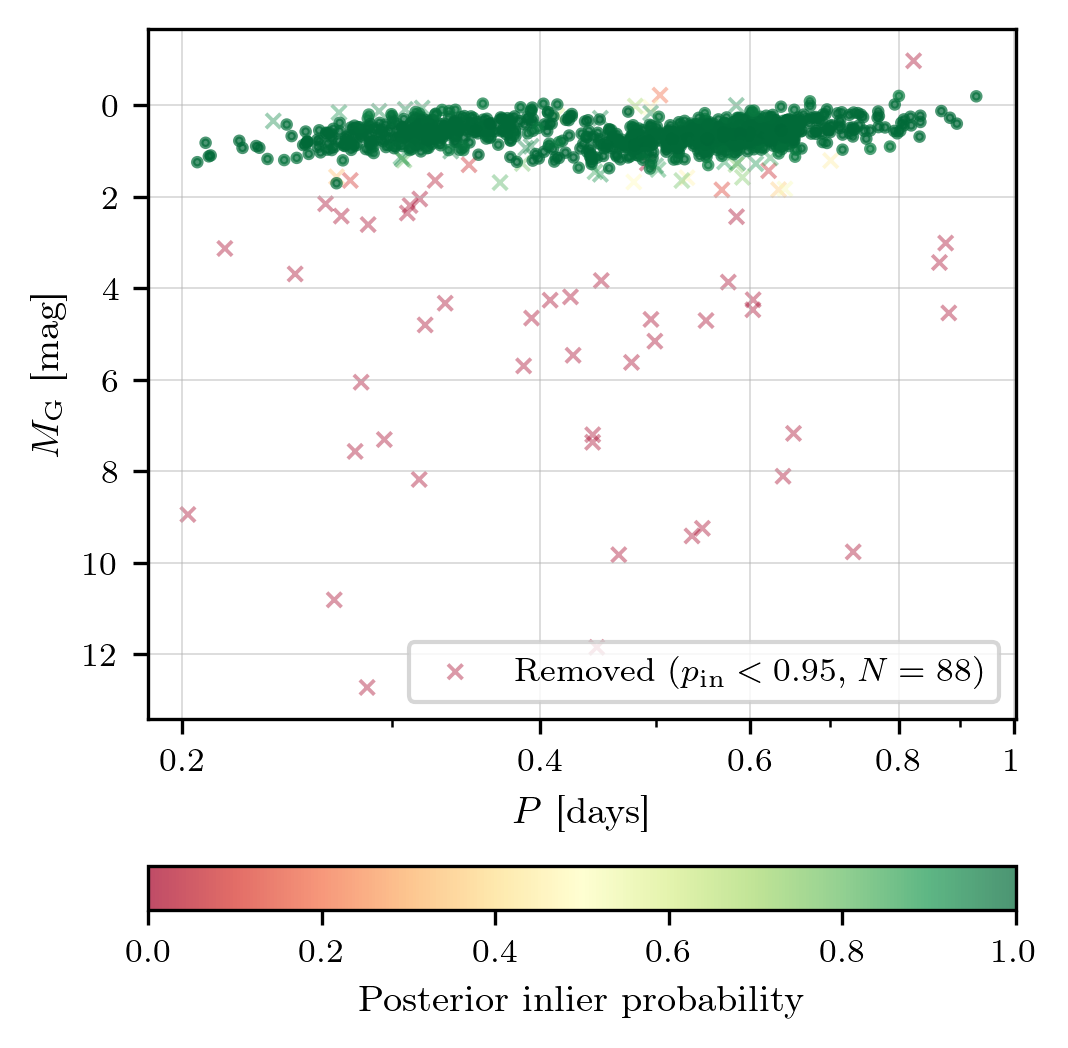

In [15]:
ax = plot_inlier_prob_period_luminosity_comparison(
    rrlyrae_mixture_clean,
    rrlyrae_calibration_data,
    rrlyrae_clean_data,
    save=True,
)
plt.show()


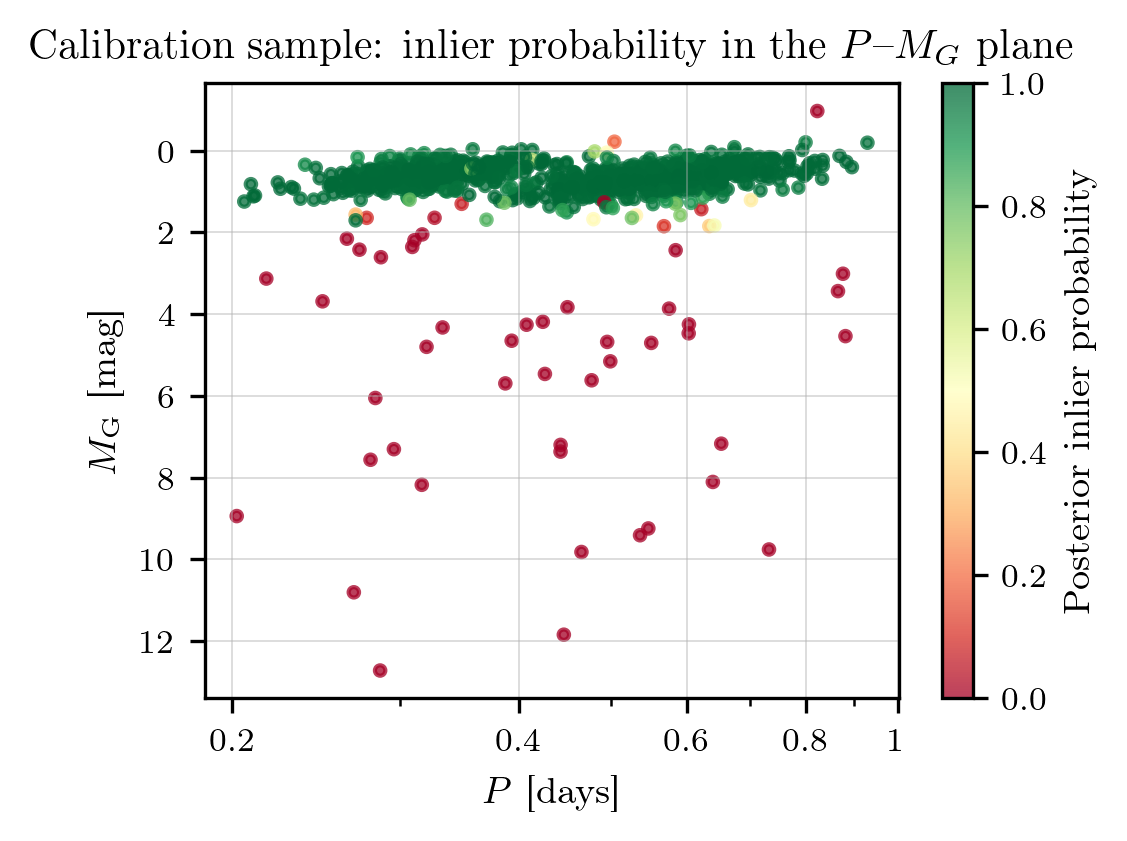

In [16]:
ax = plot_inlier_prob_map(
    rrlyrae_mixture_clean,
    save=True,
)
ax.set_title(r"Calibration sample: inlier probability in the $P$--$M_G$ plane")
plt.show()

The mixture model is more principled than a hard clip because it uses both the expected period dependence and the per-star $M_G$ uncertainty. In the current implementation the same quoted $\sigma_M$ enters both the inlier and outlier components, so stars with large distance errors are treated consistently throughout the classification step. The diagnostic probability map should therefore show that stars assigned low posterior inlier probability are concentrated in the residual tails, while the kept sample defines a much tighter main relation. That is the behavior we want from a contamination model: preserve the main RR Lyrae sequence while removing the few stars that are still inconsistent with it after the Gaia catalog-level quality cuts ([Hogg, Bovy, & Lang 2010](https://arxiv.org/abs/1008.4686); [Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html)).

The complementary residual-difference plot should be read as a diagnostic of where the sample still deviates from a simple linear locus, not as a new fit in its own right. Structure that hugs the main trend but narrows after cleaning indicates that the model is pruning inconsistent stars while leaving the core RR Lyrae relation intact. By contrast, if the cleaning step were to carve away one side of the relation or introduce a strong period-dependent bias, that would be evidence that the contamination model was distorting the astrophysics instead of isolating the tails.

One caveat is that the current `ugdatalab` mixture implementation only models RRab and RRc stars explicitly, so RRd stars are carried through unchanged. For the rest of the notebook, I use the mixture-cleaned sample as the final calibration set.


In [17]:
distance_kpc = 1.0 / rrlyrae_clean_data["parallax"]

summary = table.Table(
    {
        "source_id": rrlyrae_clean_data["source_id"],
        "best_classification": rrlyrae_clean_data["best_classification"],
        "int_average_g": rrlyrae_clean_data["int_average_g"],
        "b": rrlyrae_clean_data["b"],
        "parallax": rrlyrae_clean_data["parallax"],
        "parallax_error": rrlyrae_clean_data["parallax_error"],
        "distance_kpc": distance_kpc,
    }
)

len(summary), summary[:10]


(884,
 <Table length=10>
      source_id      best_classification ...    distance_kpc   
        int64                str4        ...      float64      
 ------------------- ------------------- ... ------------------
 5082275006547809536                RRab ...  3.730017741431232
 5098240155900394112                RRab ... 2.7695796599507867
 5083946363004134144                RRab ... 1.6815819818935613
 5089195603313822976                 RRc ... 2.0866289260312643
 5094203642556959744                RRab ... 1.9932132698838494
 5094426804761045248                RRab ... 2.4470750080564057
 3834499664603236096                 RRc ...  3.557253330028151
 3844396540563624832                RRab ... 1.6304568040539817
 3846786226007324160                 RRc ...  0.763503610253278
 3834029481648387968                RRab ...  2.127736413464041)

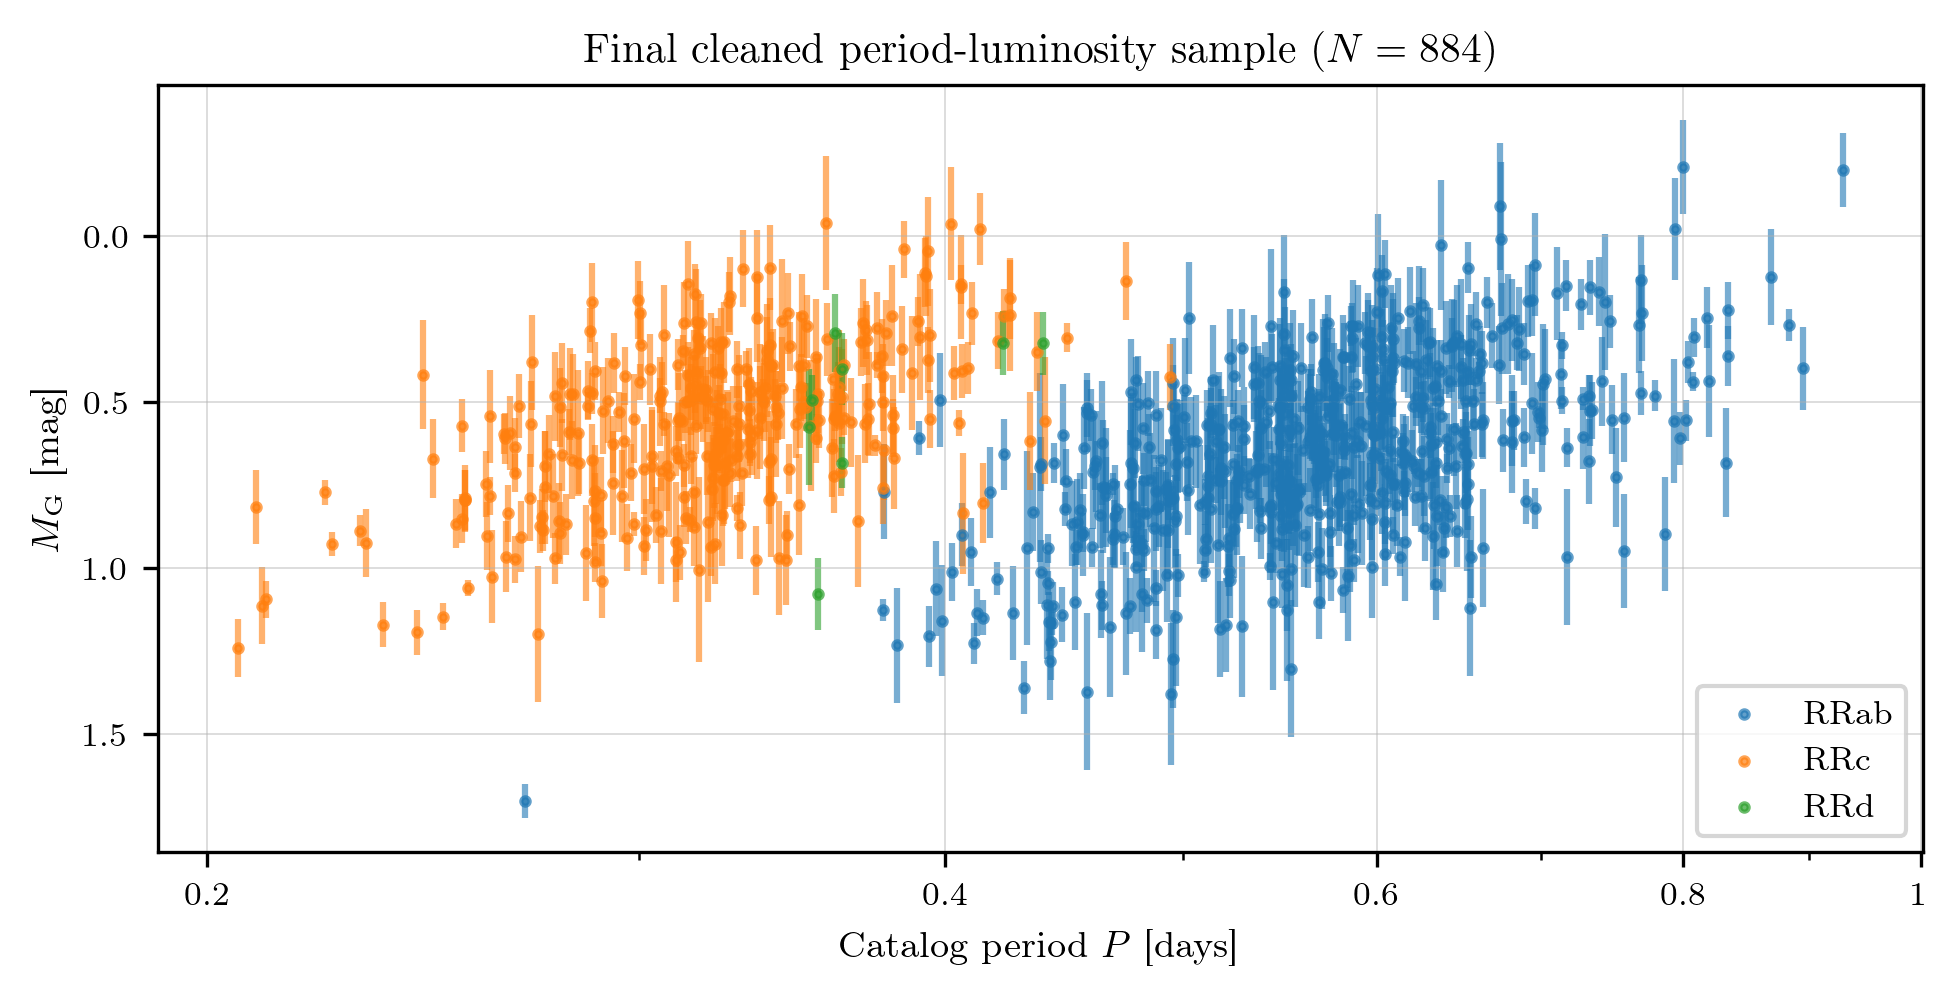

In [18]:
ax = plot_period_abs_mag(
    np.asarray(rrlyrae_clean_data["rrlyrae_representative_period"], dtype=float),
    np.asarray(rrlyrae_clean_data["M_G"], dtype=float),
    np.asarray(rrlyrae_clean_data["sigma_M"], dtype=float),
    np.asarray(rrlyrae_clean_data["best_classification"], dtype=str),
)
ax.set_title(rf"Final cleaned period-luminosity sample ($N={len(rrlyrae_clean_data)}$)")
plt.show()


In [19]:
from pathlib import Path

from ugdatalab import save_table_npz

rrlyrae_export_data = rrlyrae_clean_data.copy()
output_path = Path("rrlyrae_calibration_sample.npz")
save_table_npz(output_path, rrlyrae_export_data)

{
    "path": str(output_path.resolve()),
    "N": len(rrlyrae_export_data),
    "columns": len(rrlyrae_export_data.colnames),
}


{'path': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_calibration_sample.npz',
 'N': 884,
 'columns': 236}

The file `rrlyrae_calibration_sample.npz` is now the notebook handoff artifact for `02-02.ipynb`. That notebook should load the exported table directly instead of assuming `rrlyrae_clean_data` is already present in the kernel.
